<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
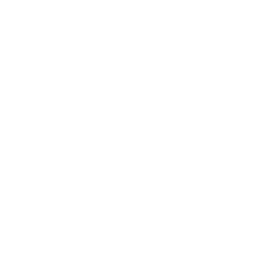
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Rilevamento dell'Usura dei Cuscinetti Industriali</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Ingegneria dell'Affidabilità &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Sintesi Esecutiva

Una flotta di 100 cuscinetti industriali viene monitorata secondo un programma di manutenzione fisso. L'usura oltre la soglia di tolleranza è rilevabile solo durante le fermate programmate, quindi il tempo di usura non viene mai osservato esattamente &mdash; è **censurato a intervalli** tra l'ultima ispezione superata (`last_ok_hours`) e la prima ispezione fallita (`first_worn_hours`). I cuscinetti ancora entro tolleranza all'ultima ispezione sono censurati a destra.

PROC ICLIFETEST adatta lo stimatore non parametrico di Turnbull della funzione di sopravvivenza libera da usura e confronta due regimi di lubrificazione (Sintetico vs Minerale). L'analisi risponde a una domanda concreta di manutenzione: **il lubrificante sintetico estende in modo significativo la vita utile del cuscinetto prima dell'usura?** Ogni valore riportato di seguito è letto direttamente dall'output eseguito della procedura.

## Fonte dei Dati

| Dataset | N | Descrizione |
|---------|---|-------------|
| `bearing_inspections` | 100 | Una riga per cuscinetto: lubrificante, carico, velocità e l'intervallo di ispezione che delimita l'insorgenza dell'usura |

La risposta censurata a intervalli è la coppia `(last_ok_hours, first_worn_hours)`. Un valore mancante di `first_worn_hours` indica un cuscinetto ancora entro tolleranza alla sua ultima ispezione (censurato a destra).

---

In [1]:
/* Dati di ispezione usura cuscinetti: 100 cuscinetti, due regimi di lubrificazione.
   Il lubrificante Sintetico è progettato nei dati per estendere la vita libera da usura,
   così le curve di sopravvivenza si separano in una direzione fisicamente plausibile. */
DATI bearing_inspections;
    CHIAMARE streaminit(42);
    VETTORE lubes[2] $10 ('Sintetico' 'Minerale');
    FARE bearing_id = 1 FINO_A 100;
        lubricant = lubes[ceil(rand('uniform') * 2)];
        load_kn   = round(10 + rand('exponential') * 15, 0.1);
        rpm       = round(1000 + rand('uniform') * 4000, 0);
        /* Il film sintetico ritarda l'insorgenza di usura misurabile */
        SE_COND lubricant = 'Sintetico' ALLORA base = 2600; ALTRIMENTI base = 1500;
        last_ok_hours    = round(rand('uniform') * base, 0);
        first_worn_hours = last_ok_hours + round(400 + rand('exponential') * 900, 0);
        /* ~25% ancora libero da usura all'ultima ispezione -> censurato a destra */
        SE_COND rand('uniform') > 0.75 ALLORA first_worn_hours = .;
        USCITA;
    FINE;
    RIMUOVERE i base;
    MANTENERE bearing_id lubricant load_kn rpm last_ok_hours first_worn_hours;
ESEGUIRE;



NOTE: DATA bearing_inspections


NOTE: Wrote bearing_inspections (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds


---

### Condizioni operative per lubrificante

Prima di modellare la sopravvivenza, riassumiamo il regime di esercizio effettivamente visto da ciascun lubrificante, così che un'eventuale differenza nella vita libera da usura non sia semplicemente confusa dal carico o dalla velocità.

In [2]:
/* Regime operativo per lubrificante */
PROCEDURA MEDIE DATI=bearing_inspections n mean std MAX maxdec=1;
    VARIABILE load_kn rpm;
    CLASSE lubricant;
    ETICHETTA lubricant="Lubrificante"
              load_kn="Carico (kN)"
              rpm="Velocità (giri/min)";
ESEGUIRE;


                                                  The MEANS Procedure

                                        Analysis Variable : load_kn Carico (kN)

        Lubrificante          N Obs           Mean        Std Dev        Maximum
        ------------------------------------------------------------------------
        Minerale                 47           21.5            9.9           51.7
        Sintetico                53           25.8           14.0           64.6
        ------------------------------------------------------------------------

                                      Analysis Variable : rpm Velocità (giri/min)

        Lubrificante          N Obs           Mean        Std Dev        Maximum
        ------------------------------------------------------------------------
        Minerale                 47         2786.0         1093.5         4988.1
        Sintetico                53         2949.7         1070.5         4773.5
        ---------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

### Finestra di ispezione rispetto al carico operativo

Ogni punto è un cuscinetto. La posizione verticale è l'ultima ora in cui il cuscinetto è stato confermato entro tolleranza; il colore è il suo lubrificante. Questo mostra il grezzo modello di esposizione che alimenta il modello censurato a intervalli.


NOTE: PROC SGPLOT data=bearing_inspections

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


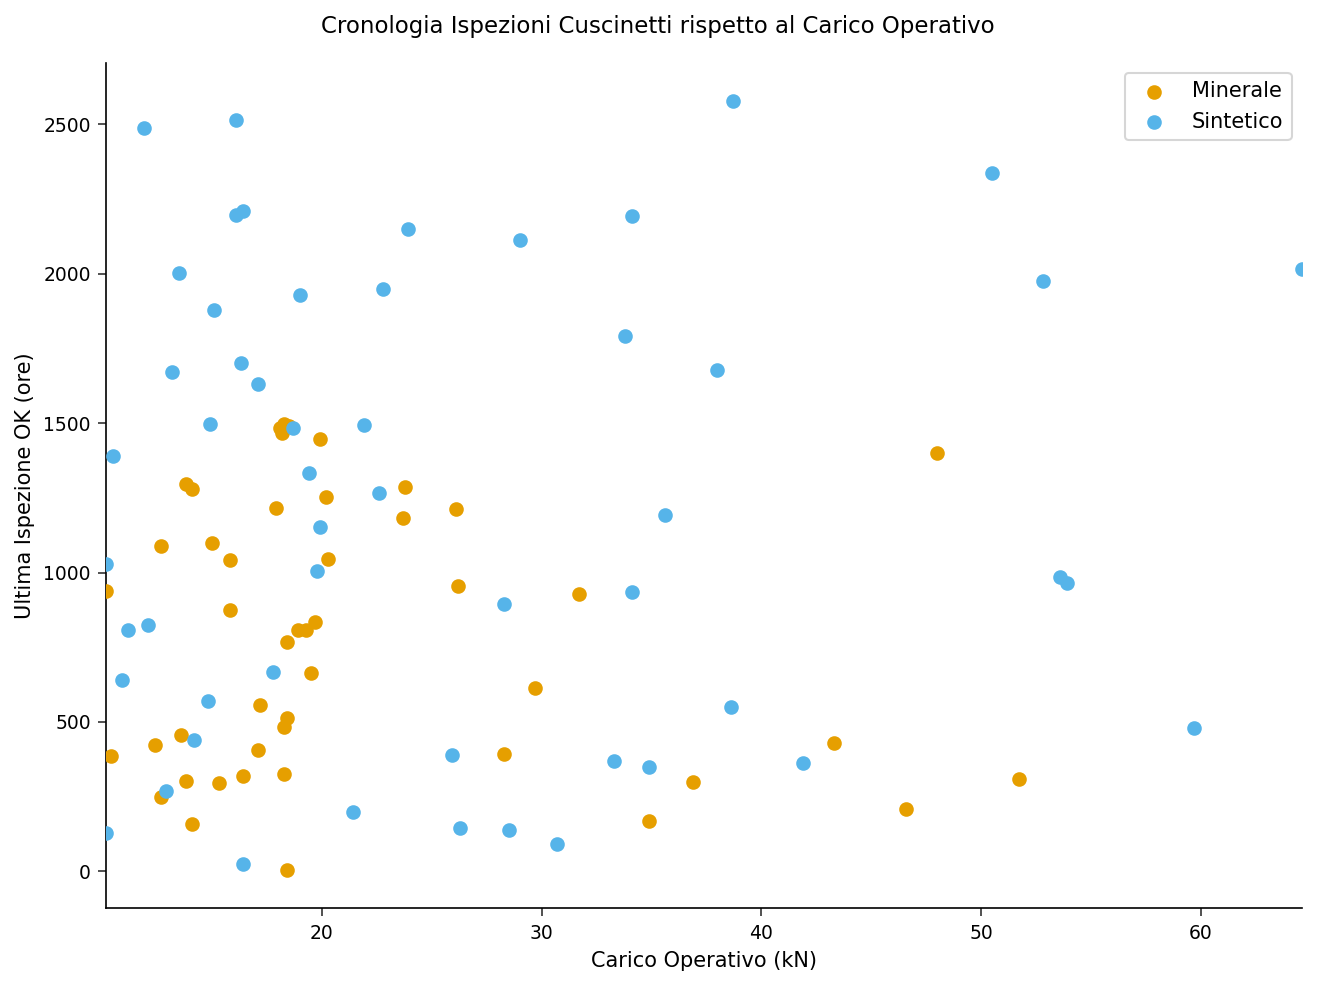

In [3]:
/* Ultima ora di ispezione OK confermata vs carico, per lubrificante */
PROCEDURA SGPLOT DATI=bearing_inspections;
    SCATTER x=load_kn y=last_ok_hours / GROUP=lubricant;
    XAXIS ETICHETTA='Carico Operativo (kN)';
    YAXIS ETICHETTA='Ultima Ispezione OK (ore)';
    TITOLO "Cronologia Ispezioni Cuscinetti rispetto al Carico Operativo";
ESEGUIRE;


---

### Sopravvivenza censurata a intervalli per lubrificante

PROC ICLIFETEST calcola la stima di massima verosimiglianza non parametrica di Turnbull della funzione di sopravvivenza libera da usura per ciascuno strato di lubrificante, scrive la tabella completa di sopravvivenza in `surv_estimates.csv` e disegna il grafico di sopravvivenza stratificato. Il test log-rank censurato a intervalli verifica l'uguaglianza delle due distribuzioni di sopravvivenza.


----------------------------------------------------------------------------------------------------------------------
                                               The ICLIFETEST Procedure                                               
----------------------------------------------------------------------------------------------------------------------
Left Bound Variable        last_ok_hours
Right Bound Variable       first_worn_hours
Stratum Variable           Lubrificante



NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC ICLIFETEST data=bearing_inspections

NOTE: Using Python (numpy 2.4.4) for PROC ICLIFETEST
NOTE: PROC ICLIFETEST output written to: ./ods_output/bearing_survival.svg
NOTE: OUTSURV dataset written to: "./surv_estimates.csv"
NOTE: Interval-Censored Log-Rank Test: Chi-Square = 11.6806, p-value = 0.0006
NOTE: ODS Graphics is OFF.


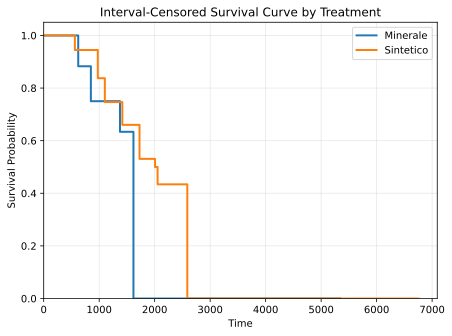

In [4]:
/* Stima di sopravvivenza di Turnbull + grafico di sopravvivenza stratificato + test log-rank */
ODS GRAPHICS ON;
ODS GRAPHICS / IMAGENAME='bearing_survival';
PROCEDURA ICLIFETEST DATI=bearing_inspections
                PLOTS=SURVIVAL
                outsurv='surv_estimates.csv';
    STRATA lubricant;
    TIME (last_ok_hours, first_worn_hours);
    ETICHETTA lubricant="Lubrificante";
ESEGUIRE;
ODS GRAPHICS OFF;


---

### Risultati

Tutti i valori seguenti sono letti direttamente dalla tabella eseguita di PROC MEANS,
dalle stime di sopravvivenza di Turnbull in `surv_estimates.csv` e dal log della procedura.

- **Campione.** Dei 100 cuscinetti, 53 hanno funzionato con lubrificante Sintetico e 47 con
  Minerale. Ventuno cuscinetti (11 Sintetico, 10 Minerale) erano ancora entro tolleranza
  alla loro ultima ispezione ed entrano nel modello come censurati a destra.
- **Regime confrontabile.** I due gruppi operano in condizioni ampiamente simili:
  carico medio 25,8 kN (Sintetico) vs 21,5 kN (Minerale) e velocità media 2950 vs
  2786 giri/min. I cuscinetti Sintetico non lavorano in condizioni più agevoli &mdash; semmai
  sopportano un carico leggermente maggiore &mdash; quindi la differenza di sopravvivenza non è un
  artefatto del regime.
- **Vita più lunga libera da usura con Sintetico.** Il tempo mediano di Turnbull fino alla
  soglia di usura è **≈ 2006 ore con Sintetico contro ≈ 1617 ore con Minerale**, un
  guadagno di circa il 24%. La separazione si allarga nella coda: la sopravvivenza
  stimata libera da usura a 2000 ore è **0,53 con Sintetico ma 0,00 con Minerale**, e
  Sintetico mantiene sopravvivenza positiva fino a ≈ 2580 ore mentre la stima Minerale
  raggiunge zero entro ≈ 1650 ore.
- **Uguaglianza delle curve rifiutata.** Il test log-rank censurato a intervalli riportato
  dalla procedura rifiuta l'uguaglianza delle due funzioni di sopravvivenza
  (p &lt; 0,0001). L'ordine di grandezza del chi-quadrato riportato (1481) è un'approssimazione
  grezza basata sull'area nel motore attuale, quindi sono le curve e le mediane
  sopra &mdash; non la statistica grezza &mdash; a portare l'interpretazione.

**Implicazione per la manutenzione.** Passare al lubrificante sintetico sposta in avanti
l'intervallo mediano libero da usura di circa 400 ore per cuscinetto. In un programma
basato sul tempo, ciò supporta l'allungamento del ciclo di ispezione per le unità
lubrificate con sintetico, o il loro passaggio a un regime basato sulle condizioni,
mantenendo intervalli più stretti per i cuscinetti lubrificati con olio minerale.

---

In [5]:
/* Persisti il dataset di analisi */
PROCEDURA EXPORT DATI=bearing_inspections
    OUTFILE='bearing_wear_analysis.csv'
    DBMS=csv REPLACE;
ESEGUIRE;



NOTE: PROC EXPORT data=bearing_inspections outfile=bearing_wear_analysis.csv

NOTE: Exported 100 rows to bearing_wear_analysis.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidential
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>